# Covariance

Components: 

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [3]:
folder = '../../fiducial-shear-noisy/fiducial/noisy-shear/'

def read_data(loc, nperm, bin_lens, bin_source):
    file = loc + f'perm_{nperm}_shear_lens{bin_lens}_source{bin_source}.txt'
    # print(file)
    sep_bin_center, weighted_sep, g_plus, g_cross, counts, weights = np.genfromtxt(file, unpack=True)
    return sep_bin_center, g_plus, g_cross, counts

In [4]:
# bin pairs from metadata.json
with open('../data/metadata.json', 'r') as f:
    metadata = json.load(f)

bin_pairs = metadata['bin_pairs']
sep_bin_center = metadata['sep_bin_center']
nperm = 1000
sigma_e = 0.26

In [5]:
signal = np.zeros((nperm, len(bin_pairs), len(sep_bin_center)))
shot_noise = np.zeros((len(bin_pairs), len(sep_bin_center)))

for i, (l, s) in enumerate(bin_pairs):
    for p in range(nperm):
        # make per number foru digits (eg. 1 --> 0001)
        p_str = str(p).zfill(4)
        sep_bin_center, g_plus, g_cross, counts = read_data(folder, p_str, l, s)
        signal[p, i, :] = g_plus
        shot_noise[i, :] = sigma_e / np.sqrt(counts) 

Plot all permutations in a given redshift bin pair to visualise realisation error.

Text(0.5, 1.0, 'All permutations for bin pair [0, 1]')

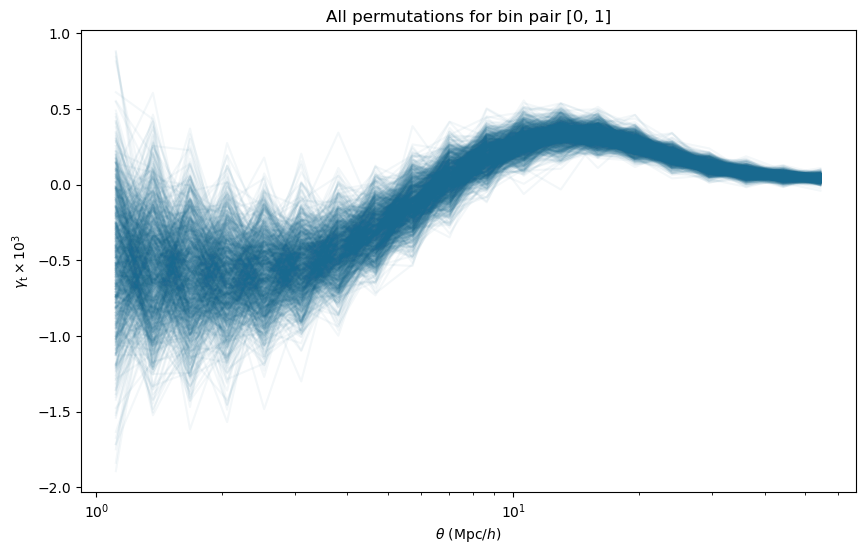

In [6]:
my_colors = ['#18698F', '#7AC011', '#FF7083']

bin_index = 0  # index of the bin pair to plot
plt.figure(figsize=(10, 6))
for p in range(nperm):
    plt.plot(sep_bin_center, signal[p, bin_index, :]*1e3, color='#18698F', alpha=0.05)
plt.xlabel(r'$\theta$ (Mpc$/h$)')
plt.ylabel(r'$\gamma_{\rm t} \times 10^3$')
plt.xscale('log')
plt.title(f'All permutations for bin pair {bin_pairs[bin_index]}')  

Compute covariance (shape noise + realisation noise + Anderson-Hartlapp correction)

Covariance matrix shape: (180, 180)


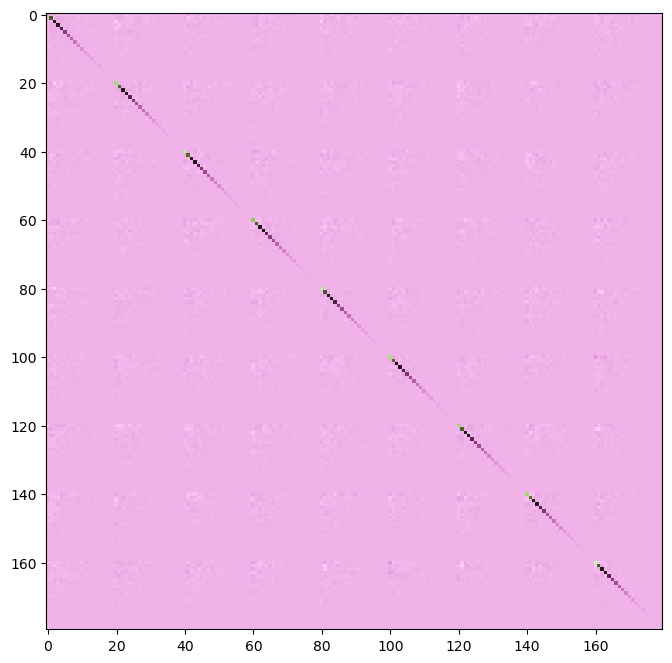

In [7]:
from matplotlib.colors import LinearSegmentedColormap

# each bin pair has 20 theta points
cov_size = len(sep_bin_center) * len(bin_pairs)
cov = np.zeros((cov_size, cov_size))

print(f"Covariance matrix shape: {cov.shape}")

# flatten each permutation into one vector [(bin0,theta0), (bin0,theta1), ...]
signal_flat = signal.reshape(nperm, cov_size)

# realisation covariance (diagonal and off diagonal)
cov = np.cov(signal_flat, rowvar=False, ddof=1)

# add shape noise variance only on diagonal
shape_variance = shot_noise.flatten() ** 2
cov[np.diag_indices_from(cov)] += shape_variance

# # Use only the middle portion of the GnBu colormap
my_blues = LinearSegmentedColormap.from_list("", ["#18698F","#7AC011"])

plt.figure(figsize=(8, 8))
plt.imshow(cov, cmap='vanimo')
plt.show()

In [8]:
inv_cov = np.linalg.inv(cov)

bias_factor = nperm - cov_size - 1 / nperm
correct_inv_cov = bias_factor * inv_cov

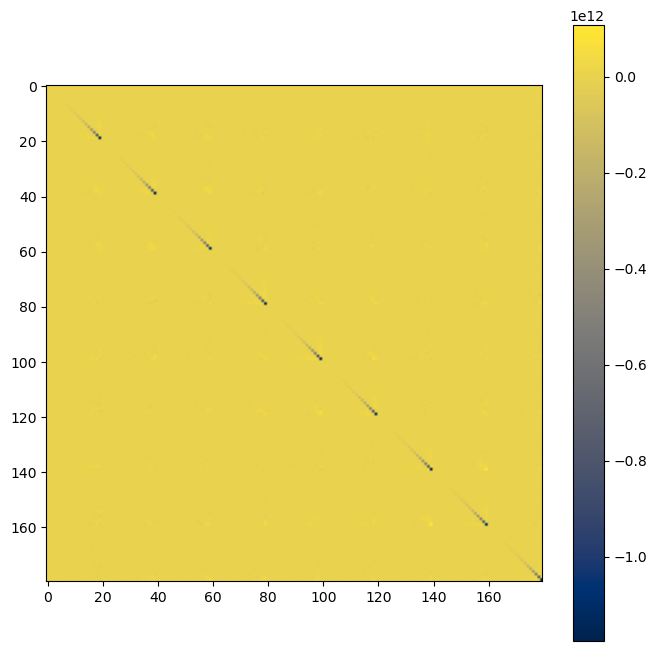

In [10]:
plt.figure(figsize=(8, 8))
plt.imshow(inv_cov - correct_inv_cov, cmap='cividis')
plt.colorbar()
plt.show()